In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── Load efficiently (pick BEFORE preload) ────────────────────────────────
def load_run(path):
    r = mne.io.read_raw_edf(path, preload=False, verbose=False)
    # Instead of just 3 channels, use the full motor cortex strip
    r.pick(['C3..', 'C4..', 'Cz..'])
    r.load_data()
    return r

Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Using matplotlib as 2D backend.


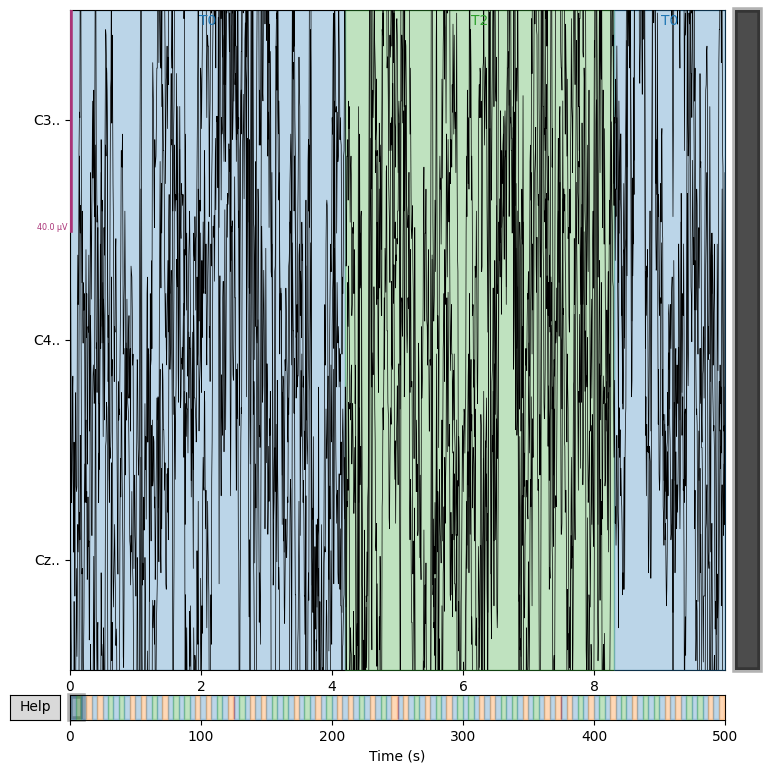

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...


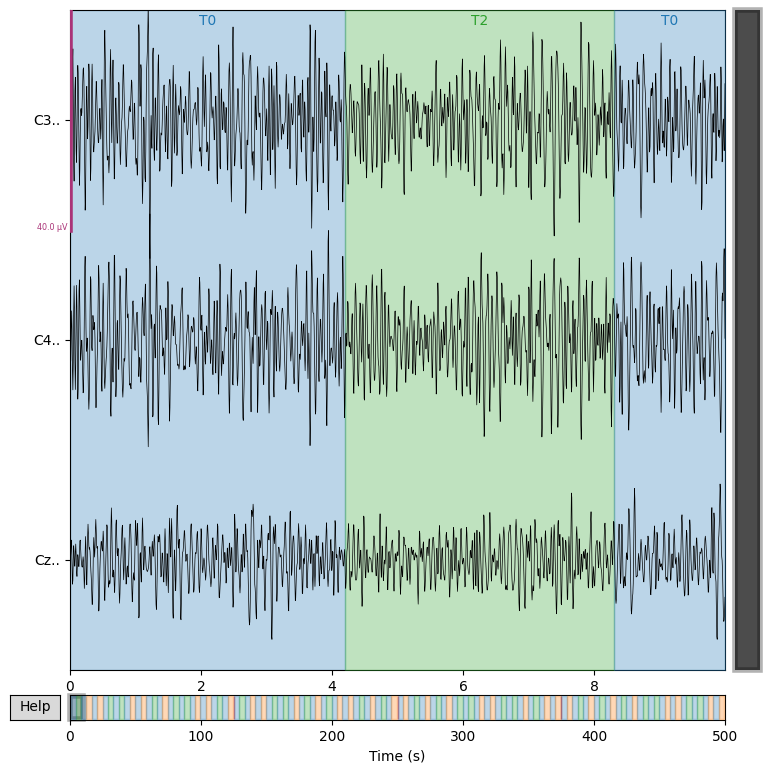

In [3]:
raw = mne.concatenate_raws([
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R03.edf"),
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R04.edf"),
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R07.edf"),
    load_run(r"C:\Users\Tarun Kumar M\OneDrive\Documents\Sem 6\Major project\archive\files\S001\S001R08.edf"),
], verbose=False)
#print(raw.ch_names)
raw.plot(title="Raw Signal")
plt.show()
   # see exactly what's available
#── Filter ────────────────────────────────────────────────────────────────
raw_filtered = raw.copy()
raw_filtered.filter(8.0, 30.0, method='fir', verbose=False)
raw_filtered.notch_filter(50, verbose=False)
raw_filtered.set_eeg_reference('average', projection=True)
raw_filtered.apply_proj()

raw_filtered.plot(title="Filtered Signal (8–30 Hz)")
plt.show()

Event IDs found: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Epochs surviving rejection: 60
Grasp:   32
Release: 28
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated


C:\Users\Tarun Kumar M\AppData\Local\Temp\ipykernel_23316\2731337598.py:19: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(0)


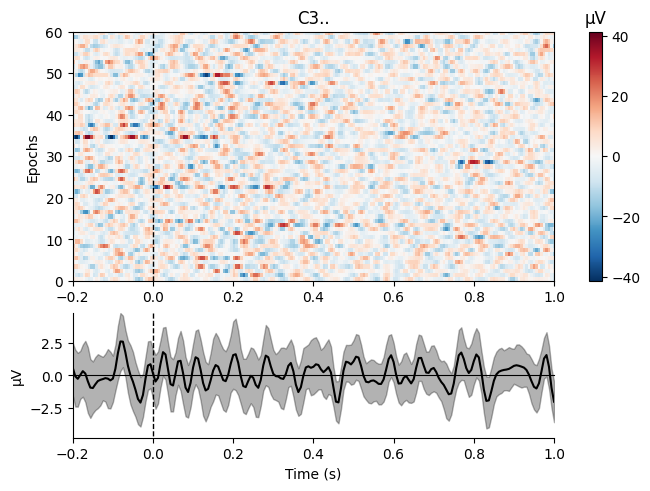

In [4]:
# ── Epoch ─────────────────────────────────────────────────────────────────
events, event_id = mne.events_from_annotations(raw_filtered, verbose=False)
print("Event IDs found:", event_id)

epochs = mne.Epochs(
    raw_filtered, events,
    event_id={'grasp': event_id['T1'], 'release': event_id['T2']},
    tmin=-0.2, tmax=1.0,
    baseline=(-0.2, 0),
    preload=True,
    reject=dict(eeg=200e-6),
    verbose=False
)

print(f"Epochs surviving rejection: {len(epochs)}")
print(f"Grasp:   {sum(epochs.events[:,2] == event_id['T1'])}")
print(f"Release: {sum(epochs.events[:,2] == event_id['T2'])}")

epochs.plot_image(0)
plt.show()


X shape: (60, 9),  Class balance: [32 28]

── Cross-validation Results ──
LDA  → 0.667 ± 0.139
SVM  → 0.633 ± 0.085
RF   → 0.617 ± 0.208

               precision    recall  f1-score   support

       grasp       0.62      0.83      0.71         6
     release       0.75      0.50      0.60         6

    accuracy                           0.67        12
   macro avg       0.69      0.67      0.66        12
weighted avg       0.69      0.67      0.66        12



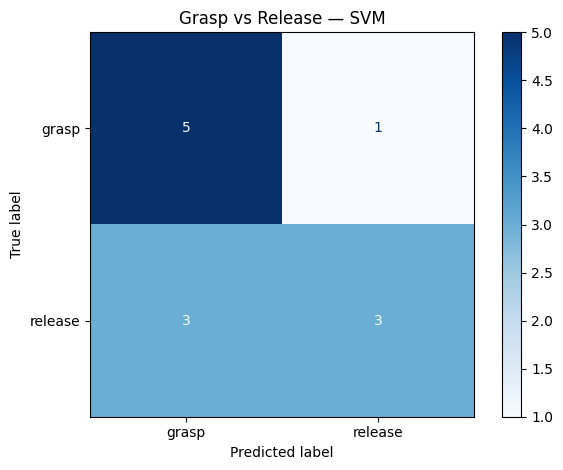

In [5]:
from scipy.signal import welch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# ── Feature Extraction ────────────────────────────────────────────────────
def extract_features(epochs):
    data = epochs.get_data()          # (n_epochs, 3, n_times)
    sfreq = epochs.info['sfreq']
    features = []
    for epoch in data:
        feats = []
        for ch in epoch:
            freqs, psd = welch(ch, fs=sfreq, nperseg=int(sfreq))
            feats.append(np.mean(psd[(freqs >= 8)  & (freqs <= 12)]))  # mu power
            feats.append(np.mean(psd[(freqs >= 13) & (freqs <= 30)]))  # beta power
            feats.append(np.var(ch))                                     # variance
        features.append(feats)
    return np.array(features)   # (n_epochs, 9)

X = extract_features(epochs)
y = LabelEncoder().fit_transform(epochs.events[:, 2])
print(f"X shape: {X.shape},  Class balance: {np.bincount(y)}")

# ── Compare 3 models ──────────────────────────────────────────────────────
models = {
    'LDA': LinearDiscriminantAnalysis(),
    'SVM': SVC(kernel='rbf', C=1.0),
    'RF' : RandomForestClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n── Cross-validation Results ──")
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    print(f"{name:4s} → {scores.mean():.3f} ± {scores.std():.3f}")

# ── Confusion matrix for best model (SVM) ────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
best = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0))])
best.fit(X_tr, y_tr)

print("\n", classification_report(y_te, best.predict(X_te), target_names=['grasp', 'release']))

ConfusionMatrixDisplay.from_predictions(
    y_te, best.predict(X_te),
    display_labels=['grasp', 'release'],
    cmap='Blues'
)
plt.title("Grasp vs Release — SVM")
plt.tight_layout()
plt.show()
